### Imputation technique in categorical data

#### I) frequent-value-imputation

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [40]:
df = pd.read_csv(
    r"C:\Users\Acer\OneDrive\Desktop\Machine Learning\CSV\train.csv", usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

In [41]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [42]:
df.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

Text(0, 0.5, 'ValueCount')

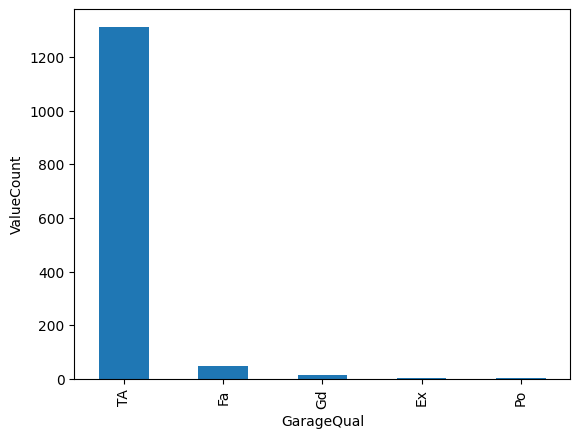

In [43]:
df['GarageQual'].value_counts().plot(kind='bar')
plt.ylabel("ValueCount")

In [44]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

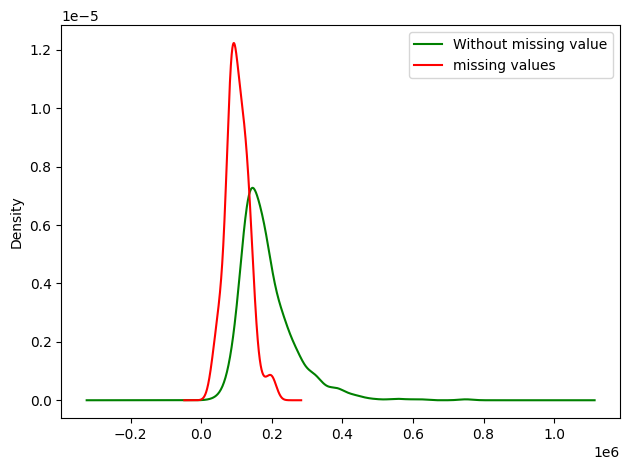

In [45]:
fig = plt.figure()
ax = fig.add_subplot(111)

df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde', ax=ax , color = 'green' ,label = 'Without missing value')
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red', label = 'missing values')

plt.legend()
plt.tight_layout()
plt.show()


In [46]:
temp = df[df['GarageQual']=='TA']['SalePrice']

In [47]:
df['GarageQual'].fillna('TA' , inplace=True)

C:\Users\Acer\AppData\Local\Temp\ipykernel_4100\2508669795.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna('TA' , inplace=True)


<Axes: xlabel='GarageQual'>

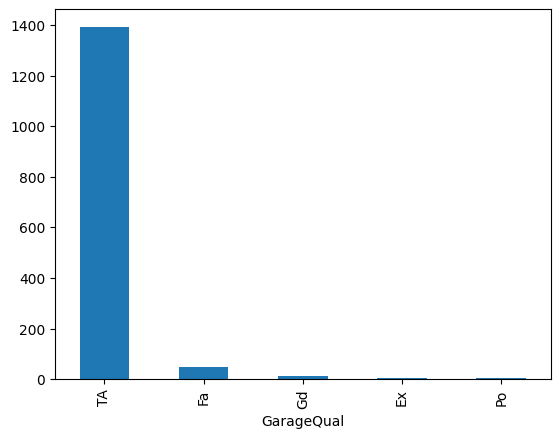

In [48]:
df['GarageQual'].value_counts().plot(kind='bar')

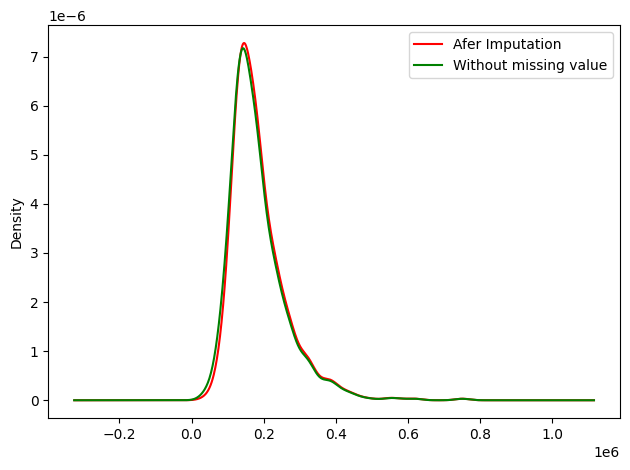

In [50]:
fig = plt.figure()
ax = fig.add_subplot(111)
temp.plot(kind='kde', ax=ax, color='red', label='Afer Imputation')
df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax, color='green', label='Without missing value')
plt.legend()
plt.tight_layout()
plt.show()

<Axes: xlabel='FireplaceQu'>

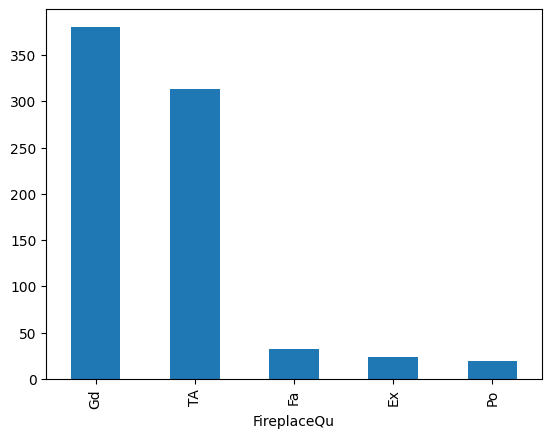

In [ ]:
df['FireplaceQu'].value_counts().plot(kind='bar')

In [ ]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

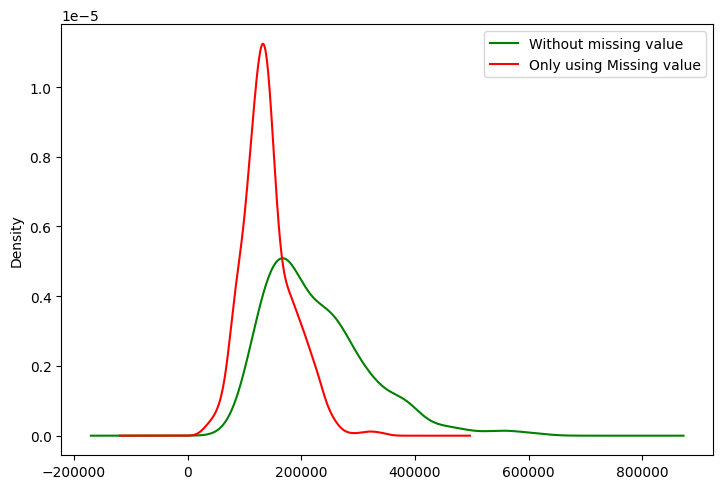

In [ ]:
fig = plt.figure(figsize=(14 , 5))
ax = fig.add_subplot(121)

df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde' , ax=ax , label = 'Without missing value' , color ='green')
df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde' , ax=ax , label = 'Only using Missing value' , color ='red')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
temp = df[df['FireplaceQu'] == 'Gd']['SalePrice']

In [ ]:
df['FireplaceQu'].fillna('Gd', inplace=True)

<Axes: xlabel='FireplaceQu'>

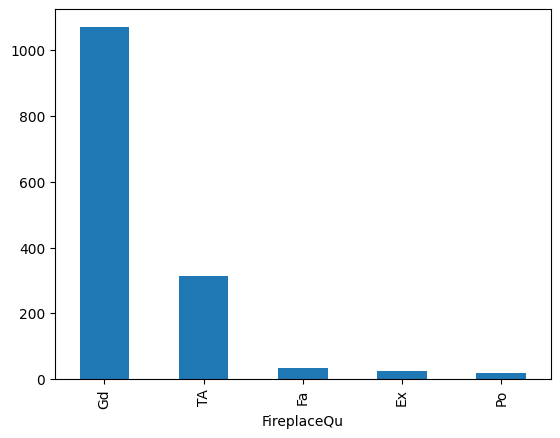

In [ ]:
df['FireplaceQu'].value_counts().plot(kind='bar')

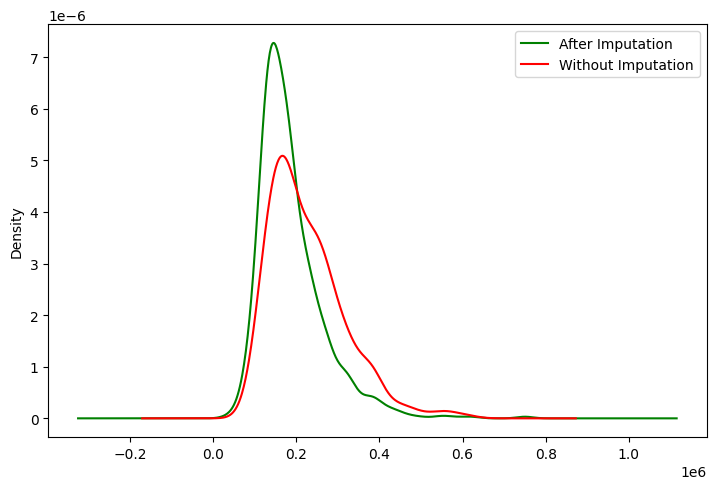

In [51]:
fig = plt.figure(figsize=(14, 5))
ax = fig.add_subplot(121)

temp.plot(kind='kde', ax=ax, label='After Imputation', color='green')
df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde', ax=ax, label='Without Imputation', color='red')
plt.legend()
plt.tight_layout()
plt.show()

In [54]:
from sklearn.model_selection import train_test_split
x = df.drop(columns=['SalePrice'])
y = df['SalePrice']
x_train , x_test , y_train , y_test = train_test_split(x , y  , test_size=0.2 , random_state=42)

In [55]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent')

In [56]:
x_train = imputer.fit_transform(x_train)
x_test = imputer.transform(x_test)

In [57]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)

### Using missing word
If data has more than 10% na then it is important to fill those na with missing word

In [58]:
df1 = pd.read_csv(
    r"C:\Users\Acer\OneDrive\Desktop\Machine Learning\CSV\train.csv", usecols=['GarageQual', 'FireplaceQu', 'SalePrice'])

Text(0, 0.5, 'ValueCount')

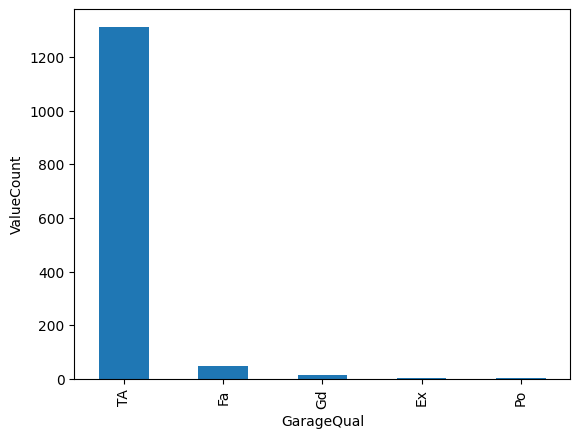

In [60]:
df1['GarageQual'].value_counts().plot(kind='bar')
plt.ylabel("ValueCount")

In [63]:
df1.fillna({'GarageQual': 'Missing'}, inplace=True)

<Axes: xlabel='GarageQual'>

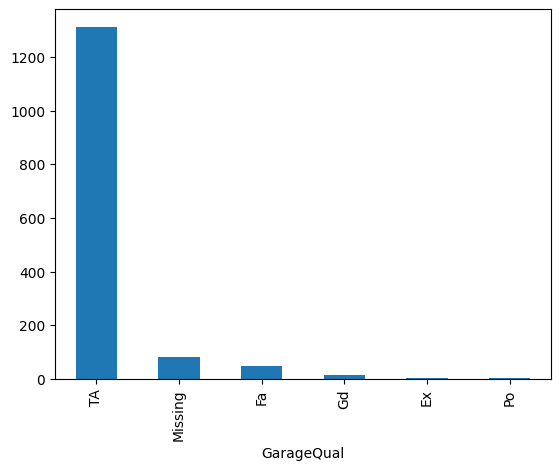

In [64]:
df1['GarageQual'].value_counts().plot(kind='bar')

In [70]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
x = df1.drop(columns=['SalePrice'])
y = df1['SalePrice']
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state=42)

In [72]:
imputer1 =  SimpleImputer(strategy='constant' , fill_value='Missing')

In [73]:
x_train = imputer1.fit_transform(x_train)
x_test = imputer1.transform(x_test)

In [74]:
imputer1.statistics_

array(['Missing', 'Missing'], dtype=object)

In [75]:
x_train

array([['Missing', 'TA'],
       ['TA', 'TA'],
       ['Missing', 'Missing'],
       ...,
       ['Missing', 'TA'],
       ['Gd', 'TA'],
       ['TA', 'TA']], shape=(1168, 2), dtype=object)